<a href="https://colab.research.google.com/github/Ubanman0135/COMP2009-Lab10/blob/main/Xor_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Streaming output truncated to the last 5000 lines.
b1:
[[-6.5627]
 [-2.7397]]
W2:
[[-9.5078  8.7917]]
b2:
[[-4.0224]]
--------------------------------------------------
Iteration  9617
Loss: 0.000361
W1:
[[4.2788 4.2711]
 [6.2705 6.2366]]
b1:
[[-6.5628]
 [-2.7397]]
W2:
[[-9.508   8.7918]]
b2:
[[-4.0224]]
--------------------------------------------------
Iteration  9618
Loss: 0.000360
W1:
[[4.2789 4.2711]
 [6.2706 6.2366]]
b1:
[[-6.5629]
 [-2.7397]]
W2:
[[-9.5081  8.792 ]]
b2:
[[-4.0225]]
--------------------------------------------------
Iteration  9619
Loss: 0.000360
W1:
[[4.2789 4.2712]
 [6.2706 6.2367]]
b1:
[[-6.5629]
 [-2.7397]]
W2:
[[-9.5082  8.7921]]
b2:
[[-4.0226]]
--------------------------------------------------
Iteration  9620
Loss: 0.000360
W1:
[[4.279  4.2712]
 [6.2707 6.2367]]
b1:
[[-6.563 ]
 [-2.7398]]
W2:
[[-9.5083  8.7922]]
b2:
[[-4.0226]]
--------------------------------------------------
Iteration  9621
Loss: 0.000360
W1:
[[4.279  4.2713]
 [6.2707 6.2367]]
b1:
[[-6.

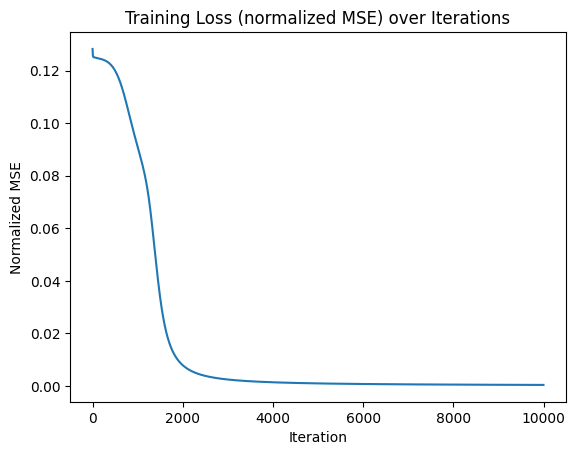


Final predictions:
Input:
[[0 0]
 [0 1]
 [1 0]
 [1 1]]
Predicted probabilities:
[[0.0285 0.975  0.9751 0.0261]]
Predicted labels:
[[0 1 1 0]]
True XOR labels:
[[0 1 1 0]]


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Activation functions
def sigmoid(z):
    """Sigmoid activation: sigma(z) = 1 / (1 + exp(-z))."""
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    """Sigmoid derivative: d_sigma(a) = a * (1 - a)"""
    return a * (1 - a)

def forward_prop(X, W1, b1, W2, b2):
    """
    Compute:
      Z1 = W1∙X + b1
      A1 = sigma(Z1)
      Z2 = W2∙A1 + b2
      A2 = sigma(Z2) <- predicted outputs
    Returns cache for back-prop.
    """
    Z1 = W1.dot(X) + b1
    A1 = sigmoid(Z1)

    Z2 = W2.dot(A1) + b2
    A2 = sigmoid(Z2)
    cache = (Z1, A1, Z2, A2)
    return A2, cache

def back_prop(X, Y, cache, W2, m: int):
    """
    Compute gradients with 1/m normalization:
        dZ2 = (A2 - Y) * sigmoid'(A2)
        dW2 = dZ2∙A1ᵀ * (1/m)
        db2 = sum(dZ2) * (1/m)
        dZ1 = W2ᵀ∙dZ2 * sigmoid'(A1)
        dW1 = dZ1∙Xᵀ * (1/m)
        db1 = sum(dZ1) * (1/m)
    Returns a dict of gradients.
    """
    Z1, A1, Z2, A2 = cache

    # Output-layer gradient
    dZ2 = (A2 - Y) * sigmoid_derivative(A2)       # shape (1, m)

    # Normalizing output-layer gradients
    dW2 = dZ2.dot(A1.T) /m                   # shape (1, 2)
    db2 = np.sum(dZ2, axis=1, keepdims=True) / m

    # Hidden-layer gradient
    dA1 = W2.T.dot(dZ2)                       # shape (2, m)
    dZ1 = dA1 * sigmoid_derivative(A1)            # sigmoid'(A1)

    # Normalizing hidden-layer gradients
    dW1 = dZ1.dot(X.T) /m                    # shape (2, 2)
    db1 = np.sum(dZ1, axis=1, keepdims=True) / m

    grads = {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}
    return grads

def predict(X_new, W1, b1, W2, b2):
    """Convert sigmoid predictions to binary outputs using 0.5"""
    A2, _ = forward_prop(X_new, W1, b1, W2, b2)
    return ((A2 >= 0.5).astype(int))

X = np.array([[0, 0, 1, 1], [0, 1, 0, 1]])

Y = np.array([[0, 1, 1, 0]])

m = X.shape[1]

# number of training examples

# Model parameters
# Two-layer neural network:
# Input layer: 2 neurons
# Hidden layer: 2 neurons
# Output layer: 1 neuron

np.random.seed(42)

W1 = np.random.randn(2, 2) * 1
b1 = np.zeros((2, 1))

W2 = np.random.randn(1, 2) * 1
b2 = np.zeros((1, 1))

# Training settings

lr = 1.0
num_iterations = 10000

# Print settings
np.set_printoptions(precision=4, suppress=True)

# Training loop
loss_history = []

for i in range(1, num_iterations + 1):
    # 1) Forward pass
    A2, cache = forward_prop(X, W1, b1, W2, b2)

    # 2) Compute normalized MSE loss
    loss = np.mean(0.5 * (A2 - Y) ** 2)
    loss_history.append(loss)

    # 3) Backward pass
    # Output-layer gradient
    grads = back_prop(X, Y, cache, W2, m)

    # 4) Parameter update
    W1 = W1 - lr * grads["dW1"]
    b1 = b1 - lr * grads["db1"]
    W2 = W2 - lr * grads["dW2"]
    b2 = b2 - lr * grads["db2"]

    # Parameter printout
    print(f"Iteration {i:5d}")
    print(f"Loss: {loss:.6f}")
    print("W1:")
    print(W1)
    print("b1:")
    print(b1)
    print("W2:")
    print(W2)
    print("b2:")
    print(b2)
    print("-" * 50)

plt.plot(loss_history)
plt.title("Training Loss (normalized MSE) over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Normalized MSE")
plt.show()


# Final predictions
print("\nFinal predictions:")
W1n, b1n, W2n, b2n = W1, b1, W2, b2
A2, _ = forward_prop(X, W1n, b1n, W2n, b2n)
preds = predict(X, W1, b1, W2, b2)

print("Input:")
print(X.T)

print("Predicted probabilities:")
print(A2)

print("Predicted labels:")
print((A2 >= 0.5).astype(int))

print("True XOR labels:")
print(Y.astype(int))